<a href="https://colab.research.google.com/github/flynnight/Tubes-Siscer/blob/main/ML_Medical_Insurance_Regresi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Perbandingan KNN dan DT Untuk Memprediksi Biaya Asuransi Kesehatan Menggunakan Variabel Smoker dan Age**

---
> **Level 2: AI-Assisted Idea Generation & Structuring**
---

## **1. Topik & Identitas**

Judul Studi Kasus: Perbandingan KNN dan Decision Tree Untuk Estimasi Biaya Asuransi Kesehatan Menggunakan Fitur Smoker dan Age

| Nama | NIM |
|------|-----|
| Fathahul Rizqa Arrahman | 103032430013 |
| Febriani Zahra | 103032400034 |
| Muhammad Maulana Darmawansyah | 103032400081 |



---
## 📦 Instalasi & Import Library

In [170]:
#untuk membaca dan mengolah dataset dalam bentuk tabel
import pandas as pd
#untuk operasi matematika dll
import numpy as np

#untuk membuat grafik (x, y)
import matplotlib.pyplot as plt
#untuk scatter plot
import matplotlib.ticker as mticker
#untuk memperjelas grafik yang dibuat oleh matplotlib
import seaborn as sns

#mengubah data teks menjadi angka
from sklearn.preprocessing import LabelEncoder
#menyamakan skala data
from sklearn.preprocessing import StandardScaler

#untuk melakukan cross validation
from sklearn.model_selection import KFold
#mencari parameter yang terbaik secara otomatis
from sklearn.model_selection import GridSearchCV
#menghasilkan prediksi dengan cross validation
from sklearn.model_selection import cross_val_predict
#untuk R^2 Score
from sklearn.model_selection import cross_val_score

#model KNN untuk regresi
from sklearn.neighbors import KNeighborsRegressor
#model DT untuk regresi
from sklearn.tree import DecisionTreeRegressor

#berguna untuk mengukur kualitas dari model yang dipake
from sklearn.metrics import (
    #MAE (mean_absolute_error) berguna untuk menghitung rata-rata selisih absolut antara nilai sebenernya dengan nilai prediksi
    mean_absolute_error,
    #RMSE (root_mean_squared_error) berguna untuk menghitung akar kuadrat dari rata-rata selisih kuadrat antara nilai sebenernya dengan nilai prediksi
    mean_squared_error,
    #r2_score untuk mengukur seberapa besar variasi data yang dapat dijelaskan oleh model
    r2_score,
    #MAPE untuk mengukur kesalahan prediksi dalam persentase
    mean_absolute_percentage_error
)

#Digunakan untuk mengimpor fungsi sqrt() dari library bawaan Python math dan sqrt adalah singkatan dari Square Root (akar kuadrat)
from math import sqrt

from scipy import stats
from scipy.stats import pointbiserialr
from scipy.stats import f_oneway
print('Semua library berhasil diimport!')

Semua library berhasil diimport!


---
## Load Dataset

> **Cara upload dataset:**  
> 1. Download file `insurance.csv` dari [Kaggle](https://www.kaggle.com/code/fredericksalazar/linear-regresion-medical-charges-insurance/input)  
> 2. Upload ke Google Colab menggunakan cell di bawah

In [171]:
#untuk membaca file yang ada didalam kolom menggunakan fungsi pandas dan menyimpannya ke dalam variabel df
df = pd.read_csv('insurance.csv')

#untuk menampilkan jumlah baris dan kolom yang ada di variabel df
print("Shape:", df.shape)
#untuk menampilkan 5 baris pertama yang ada didataset
df.head()

Shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


---
## **2. Pendahuluan & Pemaparan Data**

### **2.1. Latar Belakang & Rumusan Masalah**

Biaya asuransi kesehatan dipengaruhi oleh berbagai faktor seperti usia, BMI, dan kebiasaan merokok. Oleh karena itu dilakukan perbandingan algoritma KNN dan Decision Tree untuk memprediksi biaya asuransi kesehatan.

**Rumusan Masalah:** Bagaimana perbandingan kinerja algoritma KNN dan Decision Tree dalam mengestimasi biaya asuransi kesehatan menggunakan faktor usia dan status perokok?

**Tujuan Penelitian:** Membandingkan kinerja algoritma K-Nearest Neighbor (KNN) dan Decision Tree dalam mengestimasi biaya asuransi kesehatan menggunakan faktor usia dan status perokok.

**Target Variabel:** `charges` (kontinu, USD), ini adalah **masalah REGRESI**.


### **2.2. Deskripsi Dataset**

**Deskripsi Dataset**

"Machine Learning with R by Brett Lantz is a book that provides an introduction to machine learning using R. As far as I can tell, Packt Publishing does not make its datasets available online unless you buy the book and create a user account which can be a problem if you are checking the book out from the library or borrowing the book from a friend. All of these datasets are in the public domain but simply needed some cleaning up and recoding to match the format in the book."

**Sumber Dataset:** [Kaggle - Medical Cost Personal Datasets](https://www.kaggle.com/code/fredericksalazar/linear-regresion-medical-charges-insurance/input)

In [172]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [173]:
# Encode data object
le = LabelEncoder()

df['sex'] = le.fit_transform(df['sex'])
df['smoker'] = le.fit_transform(df['smoker'])
df['region'] = le.fit_transform(df['region'])

In [174]:
# Pecah fitur dan target
X = df[['age','smoker']]
y = df['charges']

In [175]:
# Statistik Deskriptif
#untuk menampilkan statistik deskriptif
df.describe().round(2)

,age,sex,bmi,children,smoker,region,charges
count,1338.00,1338.00,1338.00,1338.00,1338.0,1338.00,1338.00
mean,39.21,0.51,30.66,1.09,0.2,1.52,13270.42
std,14.05,0.50,6.10,1.21,0.4,1.10,12110.01
min,18.00,0.00,15.96,0.00,0.0,0.00,1121.87
25%,27.00,0.00,26.30,0.00,0.0,1.00,4740.29
50%,39.00,1.00,30.40,1.00,0.0,2.00,9382.03
75%,51.00,1.00,34.69,2.00,0.0,2.00,16639.91
max,64.00,1.00,53.13,5.00,1.0,3.00,63770.43


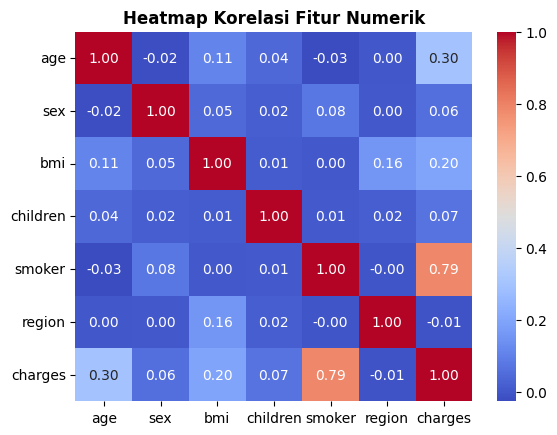

In [176]:
# Heatmap Korelasi
corr = df.corr()
sns.heatmap(
    corr,
    annot=True,      #menampilkan angka
    fmt='.2f',       #format desimal
    cmap='coolwarm', #warna
)

plt.title('Heatmap Korelasi Fitur Numerik', fontweight='bold')
plt.show()

In [177]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import pandas as pd

features = ['age', 'sex', 'bmi', 'children', 'smoker', 'region']
results = []

for feat in features:
    X_single = df[[feat]]  # harus 2D
    model = LinearRegression()
    model.fit(X_single, y)
    pred = model.predict(X_single)
    r2 = r2_score(y, pred)
    results.append({'fitur': feat, 'R2': round(r2, 4)})

result_df = pd.DataFrame(results).sort_values('R2', ascending=False)
print(result_df)

      fitur      R2
4    smoker  0.6198
0       age  0.0894
2       bmi  0.0393
3  children  0.0046
1       sex  0.0033
5    region  0.0000


Berdasarkan hasil analisis korelasi terhadap variabel target charges, smoker dan age memiliki nilai korelasi tertinggi sehingga dipilih sebagai fitur input model.

---
## 3. **Pra-Pemrosesan Data**
Pada tahap pra-pemrosesan data dilakukan seleksi fitur berdasarkan hasil analisis korelasi, yaitu usia (age) dan status perokok (smoker) sebagai variabel input serta biaya asuransi (charges) sebagai variabel target. Selanjutnya, variabel kategorikal smoker dikonversi menjadi data numerik menggunakan LabelEncoder. Data kemudian dipisahkan menjadi variabel input dan target, serta dilakukan normalisasi menggunakan StandardScaler untuk menyesuaikan skala data sebelum proses pelatihan model. Terakhir, digunakan metode K-Fold Cross Validation sebanyak 5 fold untuk memperoleh hasil evaluasi yang lebih reliabel.

### **3.1. Pembersihan Data (Cleaning)**
Dilakukan pemeriksaan missing values pada dataset menggunakan fungsi isnull().sum(). Hasil pemeriksaan menunjukkan bahwa tidak terdapat data yang hilang sehingga tidak diperlukan proses imputasi atau penghapusan data.

In [178]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


### **3.2. Transformasi Data**
Variabel smoker yang berbentuk kategorikal (yes/no) diubah menjadi bentuk numerik menggunakan LabelEncoder agar dapat diproses oleh algoritma machine learning.

Data kemudian dinormalisasi menggunakan StandardScaler untuk menyamakan skala antar fitur sehingga tidak terjadi dominasi fitur tertentu pada proses pembelajaran model.

Rumus Normalisasi:

$$z = \frac{x - \mu}{\sigma}$$

Keterangan:


* x = nilai data
* μ = rata-rata data
* σ = standar deviasi

In [179]:
# membuat objek normalisasi yang berguna untuk melakukan standarisasi data
scaler = StandardScaler()

# mengambil data dan mentransform menggunakan rumus normalisasi
X_scaled = scaler.fit_transform(X)

# Ubah kembali menjadi DataFrame
X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

X_scaled_df.head().round(2)

,age,smoker
0,-1.44,1.97
1,-1.51,-0.51
2,-0.80,-0.51
3,-0.44,-0.51
4,-0.51,-0.51


### **3.3. Penanganan Missing Values**
Berdasarkan hasil pemeriksaan, dataset tidak memiliki missing values sehingga tidak diperlukan proses penanganan data hilang.



### **3.5. Penanganan Duplicate Values**


In [180]:
df.duplicated().sum()

np.int64(1)

In [181]:
df[df.duplicated()]

,age,sex,bmi,children,smoker,region,charges
581,19,1,30.59,0,0,1,1639.5631


In [182]:
df = df.drop_duplicates()

print(df.duplicated().sum())

0


In [183]:
print("Shape:", df.shape)

Shape: (1337, 7)


### **3.4. Feature Engineering**
Pada penelitian ini tidak dilakukan proses feature engineering karena fitur yang digunakan berasal langsung dari dataset dan telah dianggap representatif untuk proses pemodelan.

---
## **4. Penanganan Imbalanced Data**

Penelitian ini menggunakan pendekatan regresi untuk mengestimasi biaya asuransi kesehatan (charges) yang berupa data numerik kontinu. Oleh karena itu, permasalahan ketidakseimbangan kelas (imbalanced data) yang umumnya ditemukan pada tugas klasifikasi tidak menjadi fokus pada penelitian ini. Dengan demikian, teknik penanganan data tidak seimbang seperti SMOTE, undersampling, oversampling, maupun class weighting tidak diterapkan.

Meskipun distribusi target charges cenderung tidak simetris (right-skewed), penelitian ini tetap menggunakan data asli tanpa teknik penyeimbangan data karena target yang diprediksi merupakan variabel kontinu.

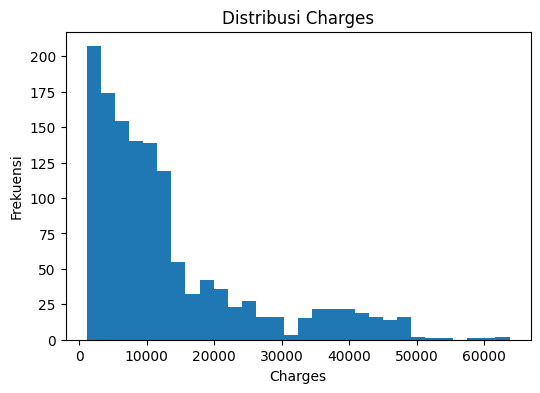

In [184]:
plt.figure(figsize=(6,4))          # ukuran grafik (lebar = 6 inci, tinggi = 4 inci)
plt.hist(df['charges'], bins=30)   # membuat histogram
plt.title('Distribusi Charges')
plt.xlabel('Charges')
plt.ylabel('Frekuensi')
plt.show()

---
## **5. Metode dan Eksperimen**

### **5.1. Konsep Algoritma**

**1. K-Nearest Neighbors Regressor**  
K-Nearest Neighbor (KNN) merupakan algoritma machine learning yang melakukan prediksi berdasarkan sejumlah tetangga terdekat dari suatu data. Pada penelitian ini, KNN digunakan untuk mengestimasi biaya asuransi kesehatan berdasarkan usia dan status perokok.

Jarak antar data biasanya dihitung menggunakan Euclidean Distance:

**Rumus Euclidean Distance:**

$$d(x, x_i) = \sqrt{\sum_{j=1}^{n}(x_j - x_{ij})^2}$$

**Keterangan:**
- $d(x, x_i)$ = jarak antara data baru $x$ dengan data latih $x_i$
- $x_j$ = nilai fitur ke-$j$ pada data baru
- $x_{ij}$ = nilai fitur ke-$j$ pada data latih ke-$i$
- $n$ = jumlah fitur
Semakin dekat jarak antar data, semakin besar pengaruh data tersebut terhadap hasil prediksi.

setelah jarak sudah memilih data yang ingin diprediksi,selanjutnya nilai prediksi diperoleh melalui rumus :

$$\hat{y} = \frac{1}{K} \sum_{i=1}^{K} y_i$$

**Keterangan:**
- $\hat{y}$ = nilai prediksi
- $K$ = jumlah tetangga terdekat yang dipilih
- $y_i$ = nilai target dari tetangga ke-$i$

**2. Decision Tree**

Decision Tree Regressor membangun struktur pohon keputusan dengan memilih pemisahan data yang menghasilkan nilai Mean Squared Error (MSE) terkecil pada setiap node. Proses ini dilakukan secara berulang hingga diperoleh struktur pohon yang mampu memprediksi nilai target dengan tingkat kesalahan yang minimum.

Rumus MSE:
$$MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y})^2$$

**Keterangan:**
- $y_i$ = nilai target aktual
- $\hat{y}$ = rata-rata nilai target pada node tersebut
- $n$ = jumlah data pada node


Nilai prediksi akhir diperoleh dari rata-rata nilai target pada *leaf node*:

$$\hat{y} = \frac{1}{n}\sum_{i=1}^{n} y_i$$

**Keterangan:**
- $\hat{y}$ = nilai prediksi
- $y_i$ = nilai target aktual pada node
- $n$ = jumlah data pada leaf node

Pada penelitian ini, Decision Tree digunakan untuk mengestimasi biaya asuransi kesehatan berdasarkan usia dan status perokok.

Keunggulan Decision Tree:


* Mudah dipahami
* Tidak memerlukan asumsi distribusi data
* Mampu menangani hubungan non-linear



### **5.2 Cross Validation**
Penelitian ini menggunakan metode K-Fold Cross Validation dengan 5 fold untuk mengevaluasi performa model. Pada metode ini, dataset dibagi menjadi lima bagian. Secara bergantian satu bagian digunakan sebagai data pengujian dan empat bagian lainnya digunakan sebagai data pelatihan. Metode ini dipilih karena mampu menghasilkan evaluasi yang lebih stabil dibandingkan pembagian data sederhana menggunakan train-test split.

In [185]:
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print(kf)

KFold(n_splits=5, random_state=42, shuffle=True)


In [186]:
# KNN
knn = KNeighborsRegressor(n_neighbors=5)

cv_knn = cross_val_score(
    knn,
    X_scaled,
    y,
    cv=kf,
    scoring='r2'
)

print("R² tiap fold KNN:")
print(cv_knn)

print("\nRata-rata R² KNN:")
print(cv_knn.mean())

R² tiap fold KNN:
[0.70472166 0.69474145 0.72650982 0.47907157 0.66165684]

Rata-rata R² KNN:
0.6533402682396552


In [187]:
# Decision Tree
dt = DecisionTreeRegressor(random_state=42)

cv_dt = cross_val_score(
    dt,
    X,
    y,
    cv=kf,
    scoring='r2'
)

print("R² tiap fold Decision Tree:")
print(cv_dt)

print("\nRata-rata R² Decision Tree:")
print(cv_dt.mean())

R² tiap fold Decision Tree:
[0.74016508 0.67222865 0.74159315 0.49415898 0.67268916]

Rata-rata R² Decision Tree:
0.6641670060090625


### **5.3 Hyperparameter Tuning dengan GridSearchCV**
GridSearchCV digunakan untuk mencari kombinasi parameter terbaik secara otomatis dengan mencoba seluruh kombinasi parameter yang telah ditentukan dan mengevaluasinya menggunakan Cross Validation.

In [188]:
# KNN
param_knn = {
    'n_neighbors': range(1, 21)
}

grid_knn = GridSearchCV(
    KNeighborsRegressor(),
    param_knn,
    cv=kf,
    scoring='r2'
)

grid_knn.fit(X_scaled, y)

print(grid_knn.best_params_)

{'n_neighbors': 20}


Hasil tersebut menunjukkan bahwa model KNN dengan 19 tetangga terdekat menghasilkan nilai R² tertinggi dibandingkan nilai n_neighbors lainnya yang diuji. Oleh karena itu, nilai n_neighbors = 19 digunakan pada model KNN akhir untuk proses evaluasi dan perbandingan dengan algoritma Decision Tree.

In [189]:
# Decision Tree
param_dt = {
    'max_depth': [3,5,7,9],
    'min_samples_split': [2,5,10]
}

grid_dt = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_dt,
    cv=kf,
    scoring='r2'
)

grid_dt.fit(X, y)

print(grid_dt.best_params_)

{'max_depth': 3, 'min_samples_split': 2}


Hyperparameter tuning dilakukan menggunakan GridSearchCV dengan kombinasi parameter max_depth sebesar 3, 5, 7, dan 9 serta min_samples_split sebesar 2, 5, dan 10. Berdasarkan hasil pencarian, kombinasi parameter terbaik yang diperoleh adalah max_depth = 3 dan min_samples_split = 2. Kombinasi tersebut menghasilkan nilai R² tertinggi pada proses 5-Fold Cross Validation sehingga digunakan pada model Decision Tree akhir.

---
## **6. Hasil & Analisis**

## **6.1. Tabel Perbandingan Metrik**
Evaluasi kinerja model dilakukan menggunakan tiga metrik regresi, yaitu Mean Absolute Error (MAE), Mean Squared Error (MSE), dan Coefficient of Determination (R² Score). Ketiga metrik tersebut digunakan untuk mengukur tingkat kesalahan prediksi serta kemampuan model dalam menjelaskan variasi data target.

**Mean Absolute Error (MAE)**

MAE mengukur rata-rata selisih absolut antara nilai aktual dan nilai prediksi.

Rumus:
$$MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$

Keterangan:


* $n$ = jumlah data
* $y_i$ = nilai aktual
* $\hat{y}_i$ = nilai prediksi

Semakin kecil nilai MAE, semakin baik performa model.

**Mean Squared Error (MSE)**

MSE mengukur rata-rata kuadrat kesalahan antara nilai aktual dan nilai prediksi.

Rumus:
$$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

Keterangan:


* $n$ = jumlah data
* $y_i$ = nilai aktual
* $\hat{y}_i$ = nilai prediksi

Semakin kecil nilai MSE, semakin baik performa model. Metrik ini memberikan penalti yang lebih besar terhadap kesalahan prediksi yang besar.

**R² Score**

R² Score mengukur kemampuan model dalam menjelaskan variasi data target.

Rumus:
$$R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}$$

Keterangan:

* $y_i$ = nilai aktual
* $\hat{y}_i$ = nilai prediksi
* $\bar{y}$ = rata-rata nilai aktual

Nilai R² berada pada rentang (−∞,1]. Semakin mendekati 1, semakin baik kemampuan model dalam menjelaskan variasi data.

**Mean Absolute Percentage Error (MAPE)**

MAPE mengukur rata-rata persentase kesalahan prediksi terhadap nilai aktual.

Rumus:
$$MAPE = \frac{100\%}{n} \sum_{i=1}^{n} \left| \frac{y_i - \hat{y}_i}{y_i} \right|$$

Keterangan:

* $n$ = jumlah data
* $y_i$ = nilai aktual
* $\hat{y}_i$ = nilai prediksi

In [190]:
# gunakan model terbaik hasil tuning
knn_best = grid_knn.best_estimator_
dt_best = grid_dt.best_estimator_

model_names = ['KNN', 'Decision Tree']

In [191]:
# Membuat prediksi KNN menggunakan 5-Fold Cross Validation
knn_pred = cross_val_predict(
    knn_best,
    X_scaled,
    y,
    cv=kf
)

# Membuat prediksi Decision Tree menggunakan 5-Fold Cross Validation
dt_pred = cross_val_predict(
    dt_best,
    X,
    y,
    cv=5
)

preds_all = [knn_pred, dt_pred]

In [192]:
# Implementasi Evaluasi
mae_knn = mean_absolute_error(y, knn_pred)
mse_knn = mean_squared_error(y, knn_pred)
rmse_knn = sqrt(mse_knn)
r2_knn = r2_score(y, knn_pred)
mape_knn = mean_absolute_percentage_error(y, knn_pred) * 100

mae_dt = mean_absolute_error(y, dt_pred)
mse_dt = mean_squared_error(y, dt_pred)
rmse_dt = sqrt(mse_dt)
r2_dt = r2_score(y, dt_pred)
mape_dt = mean_absolute_percentage_error(y, dt_pred) * 100

In [193]:
print("y         :", y[:5].values)
print("knn_pred  :", knn_pred[:5])
print()
print("y         - min:", y.min(), "| max:", y.max())
print("knn_pred  - min:", knn_pred.min(), "| max:", knn_pred.max())

y         : [16884.924    1725.5523   4449.462   21984.47061  3866.8552 ]
knn_pred  : [26806.065494    4221.36682095  6498.0847805   5928.6905185
  5805.772784  ]

y         - min: 1121.8739 | max: 63770.42801
knn_pred  - min: 1959.3142825000002 | max: 43159.938547


In [194]:
# Tabel Perbandingan Metrik
results = pd.DataFrame({
    'Model':['KNN','Decision Tree'],
    'MAE':[mae_knn, mae_dt],
    'MSE':[mse_knn, mse_dt],
    'RMSE':[rmse_knn, rmse_dt],
    'MAPE':[mape_knn, mape_dt],
    'R²':[r2_knn, r2_dt]
})



results.style.format({
    'MAE': '{:,.4f}',
    'MSE': '{:,.4f}',
    'RMSE': '{:,.4f}',
    'MAPE': '{:.2f}%',
    'R²': '{:.4f}'
})

,Model,MAE,MSE,RMSE,MAPE,R²
0,KNN,"4,195.3601","42,896,317.9294","6,549.5281",38.20%,0.7073
1,Decision Tree,"4,232.2306","42,568,330.1190","6,524.4410",41.01%,0.7095


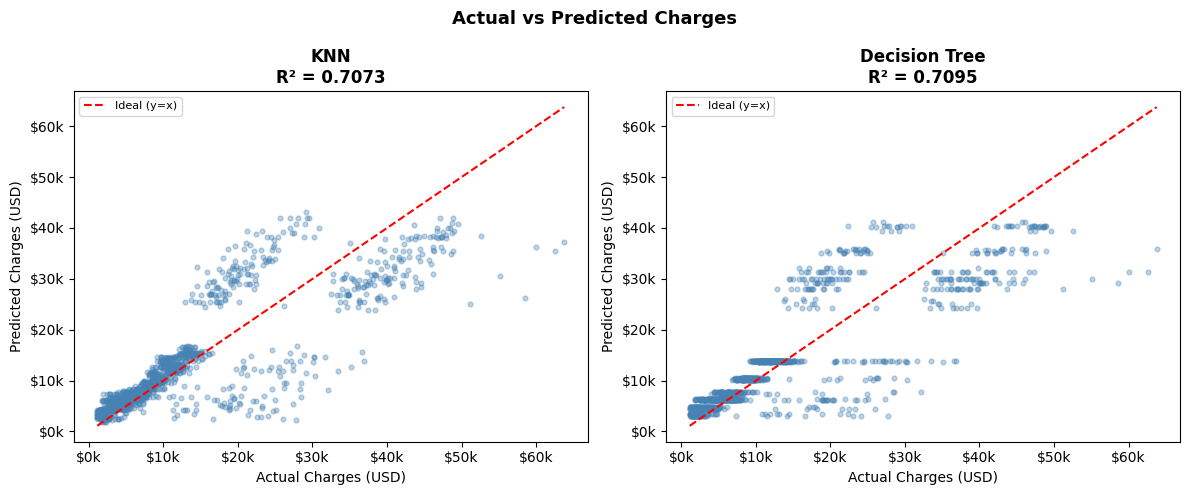

In [195]:
# Scatter Plot
# membuat 1 baris dan 2 kolom dengan lebar 12 dan tinggi 5
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Actual vs Predicted Charges', fontsize=13, fontweight='bold')

# zip(axes, model_names, preds_all) = menggabungkan 3 list sekaligus sehingga setiap iterasi dapat 1 subplot, 1 nama model, 1 array prediksi
for ax, name, pred in zip(axes, model_names, preds_all):

    # hitung R² untuk ditampilkan di judul subplot
    r2 = r2_score(y, pred)

    # alpha=0.35 → transparansi titik agar tidak menumpuk
    # s=12 → ukuran titik
    ax.scatter(y, pred, alpha=0.35, s=12, color='steelblue')

    # lims = batas sumbu x dan y disamakan agar garis ideal berbentuk diagonal 45°
    lims = [min(y.min(), pred.min()), max(y.max(), pred.max())]

    # garis merah putus-putus = kondisi ideal (prediksi == aktual)
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Ideal (y=x)')

    ax.set_xlabel('Actual Charges (USD)')
    ax.set_ylabel('Predicted Charges (USD)')
    ax.set_title(f'{name}\nR² = {r2:.4f}', fontweight='bold')

    # format sumbu x dan y dari angka asli (misal 10000) menjadi $10k
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

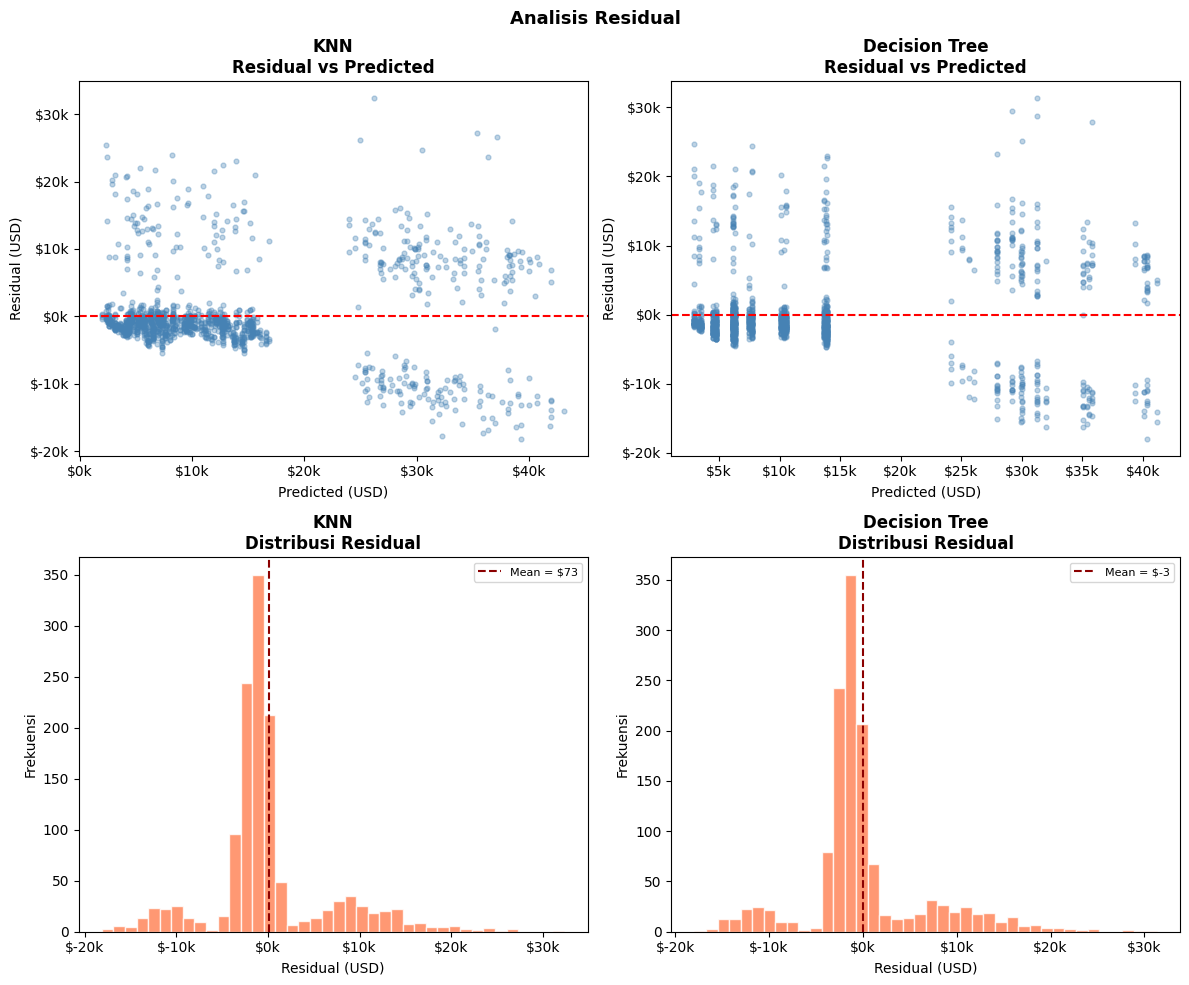

In [196]:
# Residual Analysis
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Analisis Residual', fontsize=13, fontweight='bold')

for i, (name, pred) in enumerate(zip(model_names, preds_all)):

    residuals = np.array(y) - np.array(pred)

    # Residual vs Predicted
    # titik tersebar acak di atas dan bawah garis 0
    axes[0, i].scatter(pred, residuals, alpha=0.35, s=12, color='steelblue')
    axes[0, i].axhline(0, color='red', linestyle='--', linewidth=1.5)
    axes[0, i].set_title(f'{name}\nResidual vs Predicted', fontweight='bold')
    axes[0, i].set_xlabel('Predicted (USD)')
    axes[0, i].set_ylabel('Residual (USD)')
    axes[0, i].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
    axes[0, i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

    # Distribusi Residual
    # distribusi mendekati normal dan terpusat di 0
    # bins=40 → jumlah batang histogram
    axes[1, i].hist(residuals, bins=40, color='coral', edgecolor='white', alpha=0.8)

    # garis mean residual: idealnya mendekati 0
    axes[1, i].axvline(residuals.mean(), color='darkred', linestyle='--',
                       linewidth=1.5, label=f'Mean = ${residuals.mean():,.0f}')
    axes[1, i].set_title(f'{name}\nDistribusi Residual', fontweight='bold')
    axes[1, i].set_xlabel('Residual (USD)')
    axes[1, i].set_ylabel('Frekuensi')
    axes[1, i].legend(fontsize=8)
    axes[1, i].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

plt.tight_layout()
plt.show()

---
## **7. Kesimpulan**
Penelitian ini membandingkan kinerja algoritma K-Nearest Neighbor (KNN) dan Decision Tree dalam mengestimasi biaya asuransi kesehatan menggunakan fitur usia (age) dan status perokok (smoker).

**Temuan Utama:**
Berdasarkan hasil evaluasi menggunakan 5-Fold Cross Validation, Decision Tree sedikit lebih unggul secara keseluruhan dengan R² sebesar 0.7095 dan RMSE terendah, meskipun perbedaannya tidak signifikan. KNN masih kompetitif terutama pada metrik MAE dan MAPE.

* KNN memerlukan scaling karena berbasis jarak Euclidean. Model ini performanya solid namun sensitif terhadap outlier, terutama pada segmen charges tinggi.
* Decision Tree tidak memerlukan scaling karena berbasis aturan split. Model ini mampu menangkap hubungan non-linear antara fitur dan target, namun rentan overfit tanpa pruning yang tepat.

**Rekomendasi:**

* Menambahkan fitur lain seperti BMI dan region berpotensi meningkatkan performa kedua model secara signifikan.
* Eksplorasi feature engineering, misalnya interaksi antara age dan smoker, dapat membantu model menangkap pola yang lebih kompleks.
* Penanganan outlier pada segmen charges tinggi perlu dipertimbangkan untuk mengurangi error pada rentang nilai tersebut.

In [197]:
# Tabel Ringkasan Metrik
results_summary = pd.DataFrame({
    'Model'  : ['KNN', 'Decision Tree'],
    'MAE'    : [mae_knn, mae_dt],
    'MSE'    : [mse_knn, mse_dt],
    'RMSE'   : [rmse_knn, rmse_dt],
    'MAPE'   : [mape_knn, mape_dt],
    'R²'     : [r2_knn, r2_dt]
})

# format angka agar mudah dibaca
results_display = results_summary.copy()
results_display['MAE']  = results_summary['MAE'].apply(lambda x: f'${x:,.2f}')
results_display['MSE']  = results_summary['MSE'].apply(lambda x: f'${x:,.2f}')
results_display['RMSE'] = results_summary['RMSE'].apply(lambda x: f'${x:,.2f}')
results_display['MAPE'] = results_summary['MAPE'].apply(lambda x: f'{x:.2f}%')
results_display['R²']   = results_summary['R²'].apply(lambda x: f'{x:.4f}')

print(results_display.to_string(index=False))

# model terbaik
r2_vals  = {'KNN': r2_knn,  'Decision Tree': r2_dt}
mae_vals = {'KNN': mae_knn, 'Decision Tree': mae_dt}

best_r2  = max(r2_vals,  key=r2_vals.get)
best_mae = min(mae_vals, key=mae_vals.get)

print(f'\nModel dengan R² tertinggi : {best_r2} ({r2_vals[best_r2]:.4f})')
print(f'Model dengan MAE terendah : {best_mae} (${mae_vals[best_mae]:,.2f})')
print(f'\nKesimpulan: Decision Tree sedikit lebih unggul secara keseluruhan')
print(f'(unggul di R², RMSE, dan MSE), namun selisihnya tidak signifikan.')
print(f'KNN tetap kompetitif terutama pada metrik MAE dan MAPE.')

        Model       MAE            MSE      RMSE   MAPE     R²
          KNN $4,195.36 $42,896,317.93 $6,549.53 38.20% 0.7073
Decision Tree $4,232.23 $42,568,330.12 $6,524.44 41.01% 0.7095

Model dengan R² tertinggi : Decision Tree (0.7095)
Model dengan MAE terendah : KNN ($4,195.36)

Kesimpulan: Decision Tree sedikit lebih unggul secara keseluruhan
(unggul di R², RMSE, dan MSE), namun selisihnya tidak signifikan.
KNN tetap kompetitif terutama pada metrik MAE dan MAPE.
